In [23]:
from dotenv import load_dotenv
load_dotenv()
import uuid
from typing import List
from pydantic import BaseModel,Field
from langchain_groq import ChatGroq
from langchain_core.runnables import RunnableConfig
from langgraph.graph import MessagesState,StateGraph
from langchain_core.messages import SystemMessage
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [24]:
store = InMemoryStore()

In [25]:
extractor_llm = ChatGroq(model="openai/gpt-oss-120b")

In [26]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="whether to store any memories")
    memories: List[str] = Field(default_factory=list,description="Atromic user memories to store")
    #user1 and user2 as this diffrent users gets different lists, which is why default_factory=list exists

In [27]:
memory_extractor = extractor_llm.with_structured_output(MemoryDecision)


In [28]:
# 3) Graph: START -> remember -> END

In [29]:
def remember_only_node(state:MessagesState,config:RunnableConfig,store:BaseStore):
    user_id = config['configurable']['user_id']

    namespace = ("user",user_id,"details")

    last_msg = state['messages'][-1].content

    decision : MemoryDecision = memory_extractor.invoke([
        SystemMessage(content="Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
        )
        ,{"role":"user", "content":last_msg}
    ])
  # Write to store (LTM)
    if decision.should_write:
        for memory in decision.memories:
            store.put(namespace,str(uuid.uuid4()),{"data":memory})
    # IMPORTANT: we are NOT using memory, not even responding with the LLM.
    # We just return a fixed acknowledgement.

    return {"messages":[{"role":"ai","content":"noted"}]}


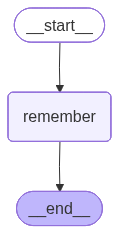

In [30]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_only_node)
builder.add_edge("__start__", "remember")
builder.add_edge("remember", "__end__")

graph = builder.compile(store=store)

graph

In [33]:
config = {"configurable": {"user_id": "u1"}}

res = graph.invoke({"messages": [{"role": "user", "content": "Hi my name isbhavya"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: noted


In [34]:
#In this the problem is of duplication
items = store.search(("user", "u1", "details"))

for item in items:
    print(item.value['data'])

User's name is Bhavya
User's name is Bhavya
User's name is Bhavya.
